# Predicting Aqueous Solubility Using Machine Learning

### Importing Libraries and Modules

In [1]:
# Importing Libraries and RDKit modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem

In [2]:
# Importing Scikit-Learn modules
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

### Loading The ESOL Dataset

In [3]:
df = pd.read_csv('delaney-processed.csv')
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


### Getting The Molecule Object from Smiles and Generating The Morgan Fingerprints

In [4]:
# Creating an RDKit Molecule object from the SMILES representation for each compound
df['Molecule'] = [Chem.MolFromSmiles(smile) for smile in df['smiles']]

# Generating the Morgan Fingerprints with radius = 2
fps_gen = AllChem.GetMorganGenerator(radius = 2, fpSize = 2048)
fps = [fps_gen.GetFingerprintAsNumPy(Molecule) for Molecule in df['Molecule']]

# Creating a new dataframe containing the generated fingerprints features
df_fps = pd.DataFrame(fps, columns=[f'fp_{x}' for x in range(2048)])
df_fps.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Combining the original dataset with the generated fingerprint features
complete_df = pd.concat([df, df_fps], axis = 1)
complete_df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,...,0,0,0,0,0,0,0,0,0,0
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2,...,0,0,0,0,0,0,0,0,0,0
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O),...,0,0,0,0,0,0,0,0,0,0
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,...,0,0,0,0,0,0,0,0,0,0
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1,...,0,0,0,0,0,0,0,0,0,0


### Setting The Predictors And the Target

In [6]:
# Defining the list of numeric molecular descriptors that will be used as features for model training and prediction
numeric_cols = ['Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area']

# Setting the predictors in a new dataframe and the target as a pandas Series
X = pd.concat([complete_df.loc[:, numeric_cols], df_fps], axis = 1)
y = complete_df['measured log solubility in mols per litre']

In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [8]:
# Applying Standard Scaler to numeric columns and pass fingerprints features unchanged
preprocessor = ColumnTransformer(transformers= [
    ('num', StandardScaler(), numeric_cols), 
    ('fp', 'passthrough', df_fps.columns)
    ]
    )

## Model Training And Evaluation

## Lasso

In [9]:
# Creating a pipeline that first applies the preprocessing steps and then fits a Lasso regression model
Lasso_model = make_pipeline(preprocessor, Lasso())

# Defining a range of alpha values on a logarithmic scale
alphas = np.logspace(-4,-1,80)

# Defining the hyperparameter grid for GridSearchCV
param_grid_Lasso = {'lasso__alpha' : alphas, 'lasso__max_iter' : [10000]}

In [10]:
# Performing hyperparameter tuning for the Lasso pipeline using GridSearchCV
Lasso_cv = GridSearchCV(estimator = Lasso_model, param_grid = param_grid_Lasso, cv = 5, n_jobs=-1, scoring='neg_mean_squared_error')

In [11]:
# Fitting the Lasso model
Lasso_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Molecular '
                                                                          'Weight',
                                                                          'Number '
                                                                          'of '
                                                                          'H-Bond '
                                                                          'Donors',
                                                                          'Number '
                                                                          'of '
                                                                          'Rings',
                                                                          'Number '
                                                                          'of '
                                                                          'Rotatable '
                                                                          'Bonds',
                                                                          'Polar '
                                                                          'Surface '
                                                                          'Area']),
                                                                        ('fp',
                                                                         'passthrough',
                                                                         Index(['fp_0', 'fp_1', 'fp_2', 'fp_3', 'fp_4', 'fp_5', 'fp_6', 'fp_7', 'fp_8',
       'fp_9',
       ...
       'fp...
       0.00792016, 0.00864388, 0.00943373, 0.01029576, 0.01123655,
       0.01226331, 0.01338389, 0.01460686, 0.01594159, 0.01739828,
       0.01898808, 0.02072315, 0.02261676, 0.0246834 , 0.02693889,
       0.02940048, 0.032087  , 0.035019  , 0.03821893, 0.04171125,
       0.04552268, 0.0496824 , 0.05422221, 0.05917686, 0.06458424,
       0.07048574, 0.0769265 , 0.08395579, 0.09162739, 0.1       ]),
                         'lasso__max_iter': [10000]},
             scoring='neg_mean_squared_error')

In [12]:
# Displaying the best hyperparameter values found by GridSearchCV
Lasso_cv.best_params_

{'lasso__alpha': np.float64(0.004294487988789272), 'lasso__max_iter': 10000}

In [13]:
# Using the best Lasso model found by GridSearchCV to generate predictions on the test set
y_pred_Lasso = Lasso_cv.predict(X_test)

# Evaluating model performance using RMSE and R² metrics
rmse_Lasso = root_mean_squared_error(y_test, y_pred_Lasso)
r2_score_Lasso = r2_score(y_test, y_pred_Lasso)

# Printing the evaluation metrics
print(f'The root mean squred error for the Lasso model is {rmse_Lasso}')
print(f'The R² score for the Lasso model is {r2_score_Lasso}')

The root mean squred error for the Lasso model is 0.9123904526634828
The R² score for the Lasso model is 0.8238859855369294


In [14]:
# Retrieving the best pipeline found during GridSearchCV
best_estimator = Lasso_cv.best_estimator_

# Accessing the Lasso model inside the pipeline
best_lasso = best_estimator.named_steps['lasso']

# Counting the number of features with non-zero coefficients
num_nonzero = np.sum(best_lasso.coef_ != 0)

print(num_nonzero)

142


#### From the trained model we observe that **142 features have non-zero coefficients**, meaning that only these descriptors contribute to the final prediction.

In [15]:
# Getting the coefficients from the trained Lasso model
coef = best_lasso.coef_

# Identifing the indices of the non-zero coefficients
selected_idx = np.where(coef != 0)[0]

# Getting the corresponding feature names
selected_features = X.columns[selected_idx]

X.loc[:, selected_features]

,Molecular Weight,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,fp_1,fp_2,fp_13,fp_23,fp_47,fp_72,...,fp_1825,fp_1847,fp_1855,fp_1866,fp_1908,fp_1911,fp_1963,fp_1982,fp_1988,fp_2029
0,457.432,3,7,202.32,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,201.225,2,2,42.24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,152.237,0,4,17.07,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,278.354,5,0,0.00,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,84.143,1,0,0.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,197.381,0,0,0.00,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1124,219.266,0,1,71.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1125,246.359,0,7,18.46,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1126,72.151,0,1,0.00,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


## Support Vector Regressor

In [16]:
# Creating a pipeline that first applies the preprocessing steps and then fits a SVR model
SVR_model = make_pipeline(preprocessor, SVR(kernel='rbf'))

In [17]:
# Defining the hyperparameter grid for GridSearchCV
param_grid_SVR = {'svr__C' : [1, 10, 100, 1000],
                  'svr__epsilon': [0.01, 0.1, 0.5, 1],
                  'svr__gamma': ['scale', 0.01, 0.1, 1, 10]
}

In [18]:
# Performing hyperparameter tuning for the SVR pipeline using GridSearchCV
SVR_cv = GridSearchCV(estimator=SVR_model, param_grid=param_grid_SVR, cv=5, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

In [19]:
# Fitting the SVR model
SVR_cv.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Molecular '
                                                                          'Weight',
                                                                          'Number '
                                                                          'of '
                                                                          'H-Bond '
                                                                          'Donors',
                                                                          'Number '
                                                                          'of '
                                                                          'Rings',
                                                                          'Number '
                                                                          'of '
                                                                          'Rotatable '
                                                                          'Bonds',
                                                                          'Polar '
                                                                          'Surface '
                                                                          'Area']),
                                                                        ('fp',
                                                                         'passthrough',
                                                                         Index(['fp_0', 'fp_1', 'fp_2', 'fp_3', 'fp_4', 'fp_5', 'fp_6', 'fp_7', 'fp_8',
       'fp_9',
       ...
       'fp_2038', 'fp_2039', 'fp_2040', 'fp_2041', 'fp_2042', 'fp_2043',
       'fp_2044', 'fp_2045', 'fp_2046', 'fp_2047'],
      dtype='object', length=2048))])),
                                       ('svr', SVR())]),
             n_jobs=-1,
             param_grid={'svr__C': [1, 10, 100, 1000],
                         'svr__epsilon': [0.01, 0.1, 0.5, 1],
                         'svr__gamma': ['scale', 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error', verbose=2)

In [20]:
# Displaying the best hyperparameter values found by GridSearchCV
SVR_cv.best_params_

{'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}

In [21]:
# Using the best SVR model found by GridSearchCV to generate predictions on the test set
y_pred_SVR = SVR_cv.predict(X_test)

# Evaluating model performance using RMSE and R² metrics
rmse_SVR = root_mean_squared_error(y_test, y_pred_SVR)
r2_score_SVR = r2_score(y_test, y_pred_SVR)

# Printing the evaluation metrics
print(f'The root mean squred error for the SVR model is {rmse_SVR}')
print(f'The R² score for the SVR model is {r2_score_SVR}')

The root mean squred error for the SVR model is 0.7646798495992758
The R² score for the SVR model is 0.8762937207599624


## Random Forest Regressor

In [22]:
# Initializing a Random Forest regression model
rfr_model = RandomForestRegressor()

In [23]:
# Defining the hyperparameter grid for RanzomizedSearchCV
param_distr_rfr_1 = {'n_estimators' : [200, 300 ,400, 500, 700],
                  'max_depth' : [None, 10, 20, 30, 40, 50],
                  'min_samples_leaf' : [1, 2, 4, 6, 8],
                  'max_features': ['sqrt', 'log2', 0.3, 0.5]
                  }

In [24]:
# Performing hyperparameter tuning for the Random Forest regressor model using RandomizedSearchCV
rfr_cv_1 = RandomizedSearchCV(estimator=rfr_model, param_distributions=param_distr_rfr_1, cv =5, n_iter=100, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

In [25]:
# Fitting the Random Forest regressor model
rfr_cv_1.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'min_samples_leaf': [1, 2, 4, 6, 8],
                                        'n_estimators': [200, 300, 400, 500,
                                                         700]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [26]:
# Displaying the best hyperparameter values found by RandomizedSearchCV
rfr_cv_1.best_params_

{'n_estimators': 500,
 'min_samples_leaf': 1,
 'max_features': 0.5,
 'max_depth': None}

### Overfitting Considerations

The hyperparameter tuning process selected a configuration with 
`max_depth = None` and `min_samples_leaf = 1`. This combination allows the 
trees in the Random Forest to grow without restriction and use very small 
leaf nodes, which may increase the risk of **overfitting**.

To assess this possibility, the model performance was evaluated on both the 
training and test sets by computing the **RMSE** and **R²** metrics.

In [27]:
# Generating predictions for the test set using the tuned Random Forest model
y_pred_rfr_1 = rfr_cv_1.predict(X_test)

# Computing RMSE for both test and training data
test_rmse_rfr_1 = root_mean_squared_error(y_test, y_pred_rfr_1)
train_rmse_rfr_1 = root_mean_squared_error(y_train, rfr_cv_1.predict(X_train))

# Computing R² scores for both training and test data
train_r2_score_rfr_1 = r2_score(y_train, rfr_cv_1.predict(X_train))
test_r2_score_rfr_1 = r2_score(y_test, y_pred_rfr_1)

# Displaing the evaluation metrics
print(f'The test RMSE for this Random Forest Regressor model is {test_rmse_rfr_1}')
print(f'The train RMSE for this Random Forest Regressor model is {train_rmse_rfr_1}\n')

print(f'The test R² score for this Random Forest Regressor model is {test_r2_score_rfr_1}')
print(f'The train R² score for this Random Forest Regressor model is {train_r2_score_rfr_1}')

The test RMSE for this Random Forest Regressor model is 0.7847608287911354
The train RMSE for this Random Forest Regressor model is 0.27347705332438876

The test R² score for this Random Forest Regressor model is 0.8697111991698464
The train R² score for this Random Forest Regressor model is 0.9826350781822878


Additionally, a second Random Forest model was trained using a slightly modified hyperparameter grid in order to explore whether a more constrained 
configuration could provide better generalization performance.

In [28]:
# Defining the second hyperparameter grid for RanzomizedSearchCV
param_distr_rfr_2 = {'n_estimators' : [200, 300 ,400, 500, 700],
                  'max_depth' : [10, 20, 30, 40, 50],
                  'min_samples_leaf' : [ 2, 4, 6, 8],
                  'max_features': ['sqrt', 'log2', 0.3, 0.5]
                  }

In [29]:
# Performing hyperparameter tuning for the second Random Forest regressor model using RandomizedSearchCV
rfr_cv_2 = RandomizedSearchCV(estimator=rfr_model, param_distributions=param_distr_rfr_2, cv =5, n_iter=100, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

In [30]:
# Fitting the second Random Forest regressor model
rfr_cv_2.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'min_samples_leaf': [2, 4, 6, 8],
                                        'n_estimators': [200, 300, 400, 500,
                                                         700]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [31]:
# Displaying the best hyperparameter values found by RandomizedSearchCV
rfr_cv_2.best_params_

{'n_estimators': 200,
 'min_samples_leaf': 2,
 'max_features': 0.5,
 'max_depth': 30}

In [32]:
# Generating predictions for the test set using the second Random Forest regressor model
y_pred_rfr_2 = rfr_cv_2.predict(X_test)

# Computing RMSE for both test and training data
test_rmse_rfr_2 = root_mean_squared_error(y_test, y_pred_rfr_2)
train_rmse_rfr_2 = root_mean_squared_error(y_train, rfr_cv_2.predict(X_train))

# Computing R² scores for  both training and test data
train_r2_score_rfr_2 = r2_score(y_train, rfr_cv_2.predict(X_train))
test_r2_score_rfr_2 = r2_score(y_test, y_pred_rfr_2)


# Displaying the evaluation metrics
print(f'The test RMSE for this Random Forest Regressor model is {test_rmse_rfr_2}')
print(f'The train RMSE for this Random Forest Regressor model is {train_rmse_rfr_2}\n')

print(f'The test R² score for this Random Forest Regressor model is {test_r2_score_rfr_2}')
print(f'The train R² score for this Random Forest Regressor model is {train_r2_score_rfr_2}')

The test RMSE for this Random Forest Regressor model is 0.7755383298630527
The train RMSE for this Random Forest Regressor model is 0.37587465316886004

The test R² score for this Random Forest Regressor model is 0.8727555096325479
The train R² score for this Random Forest Regressor model is 0.9671967306885019


In [33]:
# Creating a dictionary containing the evaluation metrics for the two Random Forest regressor models
data = {
    'Model' : ['RFR_Model_1', 'RFR_Model_2'],
    'Train_RMSE' : [round(train_rmse_rfr_1, 3), round(train_rmse_rfr_2, 3)],
    'Test_RMSE' : [round(test_rmse_rfr_1, 3), round(test_rmse_rfr_2, 3)],
    'Train_R2_Score' : [round(train_r2_score_rfr_1, 3), round(train_r2_score_rfr_2, 3)],
    'Test_R2_Score' : [round(test_r2_score_rfr_1, 3), round(test_r2_score_rfr_2, 3)]
}

In [34]:
# Converting the dictionary into a dataframe and set the model names as the index
df_data = pd.DataFrame(data).set_index('Model')

# Computing the difference between test and train RMSE
df_data['RMSE_Gap'] = df_data['Test_RMSE'] - df_data['Train_RMSE']

# Computing the difference between train and test R² scores
df_data['R2_Score_Gap'] = df_data['Train_R2_Score'] - df_data['Test_R2_Score']

df_data

,Train_RMSE,Test_RMSE,Train_R2_Score,Test_R2_Score,RMSE_Gap,R2_Score_Gap
Model,,,,,,
RFR_Model_1,0.273,0.785,0.983,0.870,0.512,0.113
RFR_Model_2,0.376,0.776,0.967,0.873,0.400,0.094


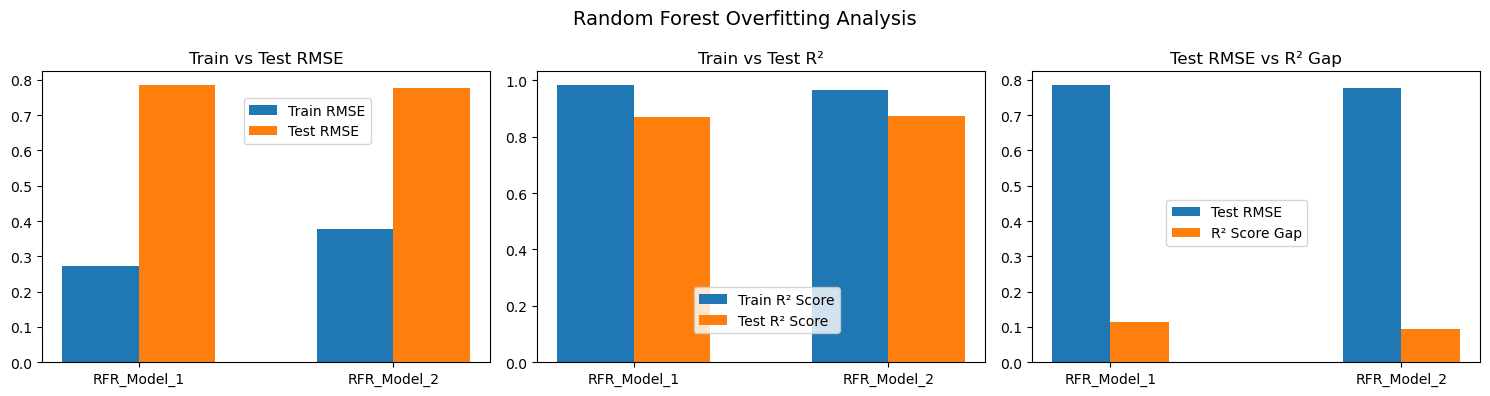

In [35]:
# Creating index positions for the models
x = range(len(df_data.index))

# Creating a figure with three subplots for model comparison
fig, axes = plt.subplots(1, 3, figsize=(15,4)) 
fig.suptitle('Random Forest Overfitting Analysis', fontsize = 14)

# -------------------------
# Plot 1: Train vs Test RMSE
# -------------------------
axes[0].bar([i-0.15 for i in x], df_data["Train_RMSE"], width=0.3, label="Train RMSE")
axes[0].bar([i+0.15 for i in x], df_data["Test_RMSE"], width=0.3, label="Test RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_data.index)
axes[0].set_title("Train vs Test RMSE")
axes[0].legend(loc=(0.45, 0.75))

# -------------------------
# Plot 2: Train vs Test R²
# -------------------------
axes[1].bar([i-0.15 for i in x], df_data["Train_R2_Score"], width=0.3, label="Train R² Score")
axes[1].bar([i+0.15 for i in x], df_data["Test_R2_Score"], width=0.3, label="Test R² Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_data.index)
axes[1].set_title("Train vs Test R²")
axes[1].legend(loc=(0.35, 0.1))

# -------------------------
# Plot 3: Test RMSE + R² Gap
# -------------------------
axes[2].bar([i-0.1 for i in x], df_data["Test_RMSE"], width=0.2, label="Test RMSE")
axes[2].bar([i+0.1 for i in x], df_data["R2_Score_Gap"], width=0.2, label="R² Score Gap")
axes[2].set_xticks(x)
axes[2].set_xticklabels(df_data.index)
axes[2].set_title("Test RMSE vs R² Gap")
axes[2].legend(loc=(0.3, 0.4))

# Adjusting layout to prevent overlap
plt.tight_layout()
plt.show()

From the comparison of the two Random Forest models, we observe that **RFR_Model_1 shows slightly stronger signs of overfitting**, as indicated by the somewhat larger gap between the training and test performance metrics.

However, **RFR_Model_1 achieves a lower test RMSE**, which indicates better predictive performance on unseen data. Since the primary goal is to optimize generalization performance, the test error is considered the most important criterion.

Therefore, **RFR_Model_1 is selected as the preferred model**, despite exhibiting a small degree of overfitting, as it provides the most accurate predictions on the test set.

## Histogram Gradient Boosting Regressor

In [36]:
# Initializing a Histogram Gradient Boosting regression model
hgbr_model = HistGradientBoostingRegressor()

In [37]:
# Defining the hyperparameter grid for RanzomizedSearchCV
param_distr_hgbr= {'max_iter' : [200, 300],
                   'learning_rate' : [0.01, 0.05, 0.1],
                  'max_depth' : [3, 7, 10],
                  'min_samples_leaf' : [10, 20],
                  'max_leaf_nodes' : [30, 65],
}

In [38]:
# Performing hyperparameter tuning for the Histogram Gradient Boosting regression model using RandomizedSearchCV
hgbr_model_cv = RandomizedSearchCV(estimator=hgbr_model, param_distributions=param_distr_hgbr, cv=5, random_state=42, n_iter=30, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

In [39]:
# Fitting the Histogram Gradient Boosting regression model
hgbr_model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=HistGradientBoostingRegressor(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 7, 10],
                                        'max_iter': [200, 300],
                                        'max_leaf_nodes': [30, 65],
                                        'min_samples_leaf': [10, 20]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [40]:
# Displaying the best hyperparameter values found by RandomizedSearchCV
hgbr_model_cv.best_params_

{'min_samples_leaf': 10,
 'max_leaf_nodes': 30,
 'max_iter': 200,
 'max_depth': 7,
 'learning_rate': 0.1}

In [41]:
# Using the best Histogram Gradient Boosting regressor model found by GridSearchCV to generate predictions on the test set
y_pred_hgbr = hgbr_model_cv.predict(X_test)

# Evaluating model performance using RMSE and R² metrics
rmse_hgbr = root_mean_squared_error(y_test, y_pred_hgbr)
r2_score_hgbr = r2_score(y_test, y_pred_hgbr)


# Printing the evaluation metrics
print(f'The root mean squred error for the Histogram Gradient Boosting regressor model is {rmse_hgbr}')
print(f'The R² score for the Histogram Gradient Boosting regressor model is {r2_score_hgbr}')

The root mean squred error for the Histogram Gradient Boosting regressor model is 0.6951083112037494
The R² score for the Histogram Gradient Boosting regressor model is 0.8977796378928705


## Model Evaluation and Comparison

In [42]:
# Creating a dictionary containing the evaluation metrics for all 4 models
evaluation_data = {
    'Model' : ['Lasso', 'SVR', 'Random_Forest', 'Hist_Gradient_Boosting'],
    'Test_RMSE' : [round(rmse_Lasso, 3), round(rmse_SVR, 3), round(test_rmse_rfr_1, 3), round(rmse_hgbr, 3)],
    'Test_R2_Score' : [round(r2_score_Lasso, 3), round(r2_score_SVR, 3), round(test_r2_score_rfr_1, 3), round(r2_score_hgbr, 3)]
}

In [43]:
# Creating a dataframe summarizing the test performance of all models and rank them based on their Test RMSE
evaluation_df = pd.DataFrame(evaluation_data).set_index('Model')
evaluation_df['RMSE_Rank'] = evaluation_df['Test_RMSE'].rank(ascending=True)
evaluation_df.sort_values(by='RMSE_Rank', inplace=True)

evaluation_df

,Test_RMSE,Test_R2_Score,RMSE_Rank
Model,,,
Hist_Gradient_Boosting,0.695,0.898,1.0
SVR,0.765,0.876,2.0
Random_Forest,0.785,0.870,3.0
Lasso,0.912,0.824,4.0


<Axes: xlabel='Model'>

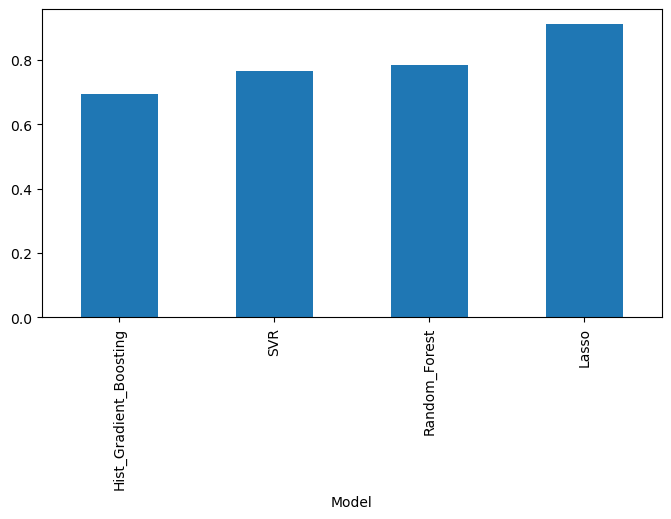

In [44]:
# Visualizing the Test RMSE of all models using a bar plot to compare their prediction errors
evaluation_df['Test_RMSE'].plot(kind = 'bar', figsize=(8,4))

From the comparison of the evaluation metrics, we observe that the **Histogram Gradient Boosting Regressor** achieves the **lowest Test RMSE** among all the tested models.

Since RMSE directly measures the prediction error on unseen data, a lower value indicates better generalization performance. Based on this criterion, the **Histogram Gradient Boosting model is selected as the final model**, as it provides the most accurate predictions on the test set compared to the other approaches.

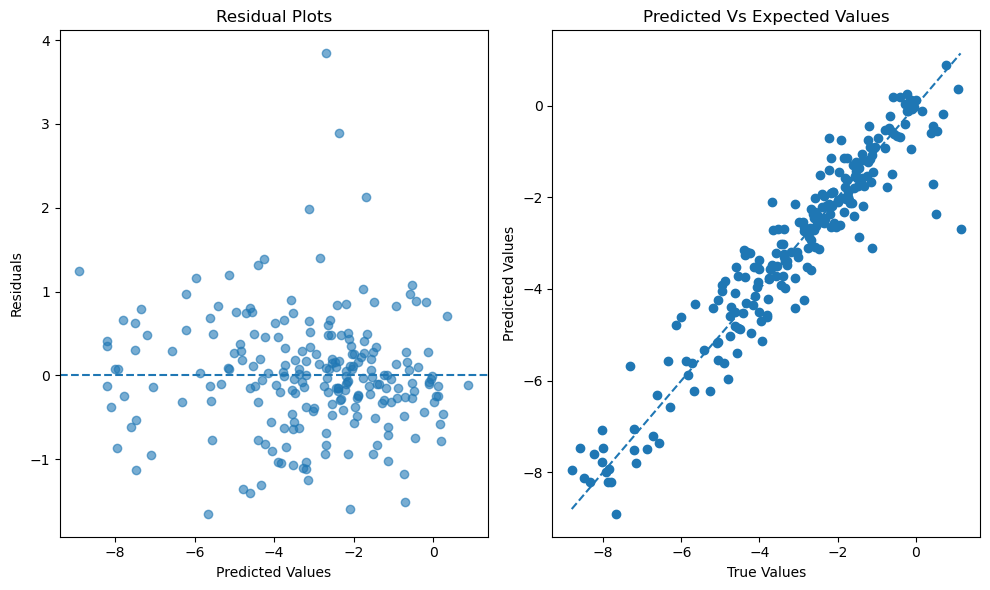

In [45]:
# Computing residuals (difference between true and predicted values)
residuals = y_test - y_pred_hgbr

# Creating two diagnostic plots for model evaluation
fig, axes = plt.subplots(1,2, figsize = (10,6))

# -------------------------
# Plot 1: Residuals
# Used to check whether residuals are randomly distributed around zero
# -------------------------

axes[0].scatter(x = y_pred_hgbr, y = residuals, alpha = 0.6)
axes[0].set_title('Residual Plots')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].axhline(y=0, linestyle = '--')

# -------------------------
# Plot 2: Predicted Vs Expected Values
# Shows how close predictions are to the actual values
# -------------------------

axes[1].scatter(x = y_test, y = y_pred_hgbr)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             linestyle = '--')
axes[1].set_title('Predicted Vs Expected Values')
axes[1].set_xlabel('True Values')
axes[1].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

### Diagnostic Plot Interpretation

The **residual plot** shows that the residuals are generally centered around zero and appear randomly distributed, indicating that the model does not exhibit strong systematic bias. A few larger residuals (outliers) are present, and slightly higher variance is observed at very low predicted values.

In the **Predicted vs True Values** plot, most points lie close to the diagonal line (y = x), suggesting that the model predictions closely match the actual values across the range of the data. A slight tendency to underestimate very high solubility values can be observed, which is a typical behavior in boosting-based models.

Overall, the plots are consistent with the evaluation metrics (RMSE ≈ 0.695, R² ≈ 0.898), indicating strong predictive performance on the ESOL dataset.

### Feature Importance Analysis

In [46]:
# Retrieving the best Histogram Gradient Boosting regressor model found during hyperparameter tuning
best_model = hgbr_model_cv.best_estimator_

# Computing permutation feature importance on the test set
important_features = permutation_importance(best_model, X_test, y_test, n_repeats = 10, random_state=42, n_jobs=-1,  scoring = 'neg_mean_squared_error')

In [47]:
# Creating a dataframe with feature names and their mean permutation importance
important_features_df = pd.DataFrame({'Feature' : X.columns,
                                      'Importance' : important_features.importances_mean})

# Sorting features by importance in descending order
important_features_df.sort_values(by = 'Importance', ascending=False, ignore_index = True, inplace = True)

# Selecting the top 20 most important features
top_features = important_features_df.head(20)

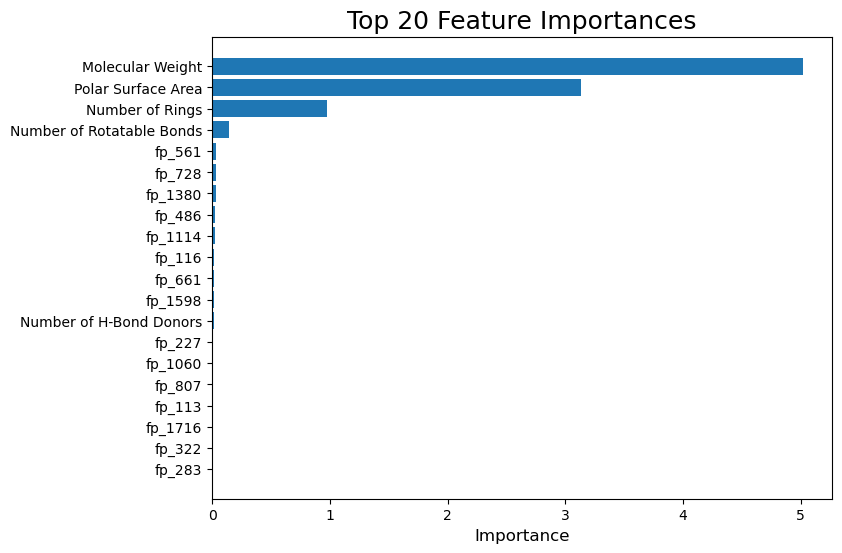

In [48]:
# Plotting the top 20 most important features as a horizontal bar chart
plt.figure(figsize=(8,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances', fontsize = 18)
plt.xlabel('Importance', fontsize = 12)

plt.show()

### Interpretation of Top 20 Feature Importances

From the horizontal bar plot, we can see that **Molecular Weight** and **Polar Surface Area** are the most influential features for predicting solubility in this dataset. 

Other molecular descriptors, such as **Number of Rings** and **Number of Rotatable Bonds**, also contribute but to a lesser extent. 

Most of the remaining features are fingerprint bits, which have relatively small importance values individually. This suggests that **global molecular descriptors drive most of the predictive power**, while the fingerprints provide finer details.